# 🖼️ Image Classification using CNN
### Transfer Learning with ResNet50
**Dataset:** Intel Image Classification (Kaggle)
**Classes:** buildings | forest | glacier | mountain | sea | street

## 📦 Step 1 — Install Dependencies

In [3]:
!pip install kaggle -q
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings; warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 🔑 Step 2 — Upload kaggle.json API Key

In [2]:
from google.colab import files
files.upload()   # upload your kaggle.json here

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle API key configured!")

Saving kaggle.json to kaggle.json
✅ Kaggle API key configured!


## 📥 Step 3 — Download Dataset

In [3]:
!kaggle datasets download -d puneet6060/intel-image-classification -p /content/
!unzip -q /content/intel-image-classification.zip -d /content/data/
!ls /content/data/

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:05<00:00, 65.6MB/s]

seg_pred  seg_test  seg_train


## ⚙️ Step 4 — Configuration

In [4]:
TRAIN_DIR = '/content/data/seg_train/seg_train'
TEST_DIR  = '/content/data/seg_test/seg_test'
IMG_SIZE  = 150; BATCH_SIZE = 32; EPOCHS = 25; LEARNING_RATE = 1e-4; SEED = 42
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
tf.random.set_seed(SEED); np.random.seed(SEED)
print("Train classes:", sorted(os.listdir(TRAIN_DIR)))

Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 📁 Step 5 — Data Generators + Augmentation

In [5]:
train_datagen = ImageDataGenerator(rescale=1/255, rotation_range=20,
    width_shift_range=0.15, height_shift_range=0.15, shear_range=0.1,
    zoom_range=0.15, horizontal_flip=True, fill_mode='nearest', validation_split=0.1)
test_datagen = ImageDataGenerator(rescale=1/255)

train_gen = train_datagen.flow_from_directory(TRAIN_DIR, target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', subset='training', seed=SEED)
val_gen   = train_datagen.flow_from_directory(TRAIN_DIR, target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', subset='validation', seed=SEED)
test_gen  = test_datagen.flow_from_directory(TEST_DIR, target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## 🔍 Step 6 — Visualize Samples

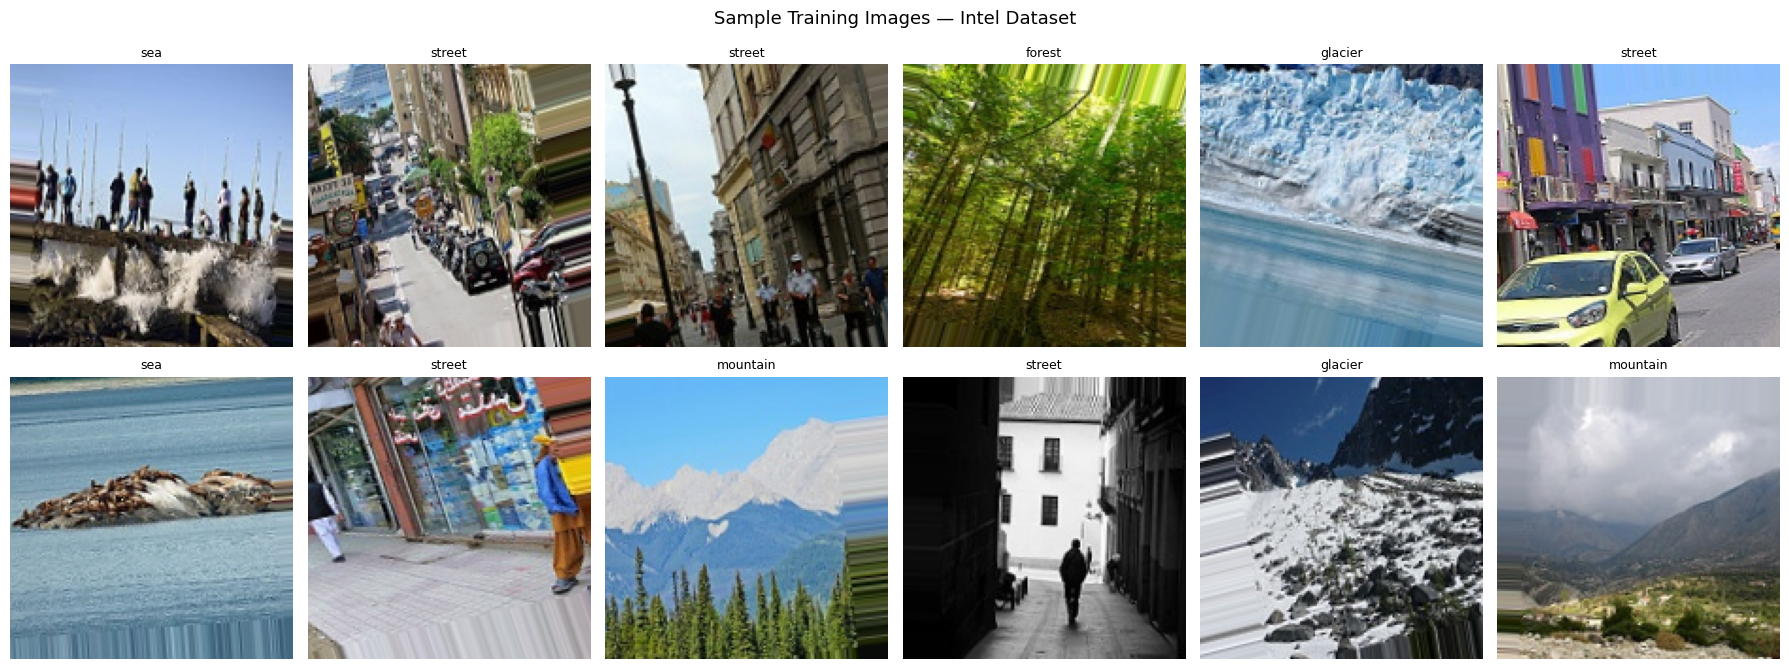

In [6]:
X_b, y_b = next(train_gen)
labels = list(train_gen.class_indices.keys())
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_b[i]); ax.set_title(labels[np.argmax(y_b[i])], fontsize=9); ax.axis('off')
plt.suptitle('Sample Training Images — Intel Dataset', fontsize=13)
plt.tight_layout(); plt.show()

## 🏗️ Step 7 — Build Model (ResNet50 + Custom Head)

In [7]:
base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
for layer in base.layers[:-20]: layer.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])
model.compile(optimizer=optimizers.Adam(LEARNING_RATE),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,705,286 (94.24 MB)

 Trainable params: 10,047,878 (38.33 MB)

 Non-trainable params: 14,657,408 (55.91 MB)

## 🚀 Step 8 — Train

In [ ]:
cb_list = [
    callbacks.EarlyStopping(patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    callbacks.ModelCheckpoint('/content/imgcls_best.h5', save_best_only=True, verbose=1)
]
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=cb_list)

Epoch 1/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4272 - loss: 1.5455
Epoch 1: val_loss improved from None to 1.63198, saving model to /content/imgcls_best.h5



Epoch 1: finished saving model to /content/imgcls_best.h5
395/395 ━━━━━━━━━━━━━━━━━━━━ 1730s 4s/step - accuracy: 0.4880 - loss: 1.3488 - val_accuracy: 0.3295 - val_loss: 1.6320 - learning_rate: 1.0000e-04
Epoch 2/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5689 - loss: 1.1147
Epoch 2: val_loss did not improve from 1.63198
395/395 ━━━━━━━━━━━━━━━━━━━━ 1754s 4s/step - accuracy: 0.5827 - loss: 1.0850 - val_accuracy: 0.3638 - val_loss: 1.9696 - learning_rate: 1.0000e-04
Epoch 3/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5952 - loss: 1.0410
Epoch 3: val_loss did not improve from 1.63198
395/395 ━━━━━━━━━━━━━━━━━━━━ 1715s 4s/step - accuracy: 0.6001 - loss: 1.0230 - val_accuracy: 0.4494 - val_loss: 2.1046 - learning_rate: 1.0000e-04
Epoch 4/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6282 - loss: 0.9728
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 4: val_loss did not improve from 1.63198
395/395 ━━━━━━━━━━━━━━━━━━━


Epoch 5: finished saving model to /content/imgcls_best.h5
395/395 ━━━━━━━━━━━━━━━━━━━━ 1707s 4s/step - accuracy: 0.6549 - loss: 0.9137 - val_accuracy: 0.5093 - val_loss: 1.3760 - learning_rate: 5.0000e-05
Epoch 6/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6704 - loss: 0.8987
Epoch 6: val_loss did not improve from 1.37597
395/395 ━━━━━━━━━━━━━━━━━━━━ 1756s 4s/step - accuracy: 0.6655 - loss: 0.8873 - val_accuracy: 0.4422 - val_loss: 2.1453 - learning_rate: 5.0000e-05
Epoch 7/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6714 - loss: 0.8763
Epoch 7: val_loss improved from 1.37597 to 1.15416, saving model to /content/imgcls_best.h5



Epoch 7: finished saving model to /content/imgcls_best.h5
395/395 ━━━━━━━━━━━━━━━━━━━━ 1704s 4s/step - accuracy: 0.6714 - loss: 0.8644 - val_accuracy: 0.5499 - val_loss: 1.1542 - learning_rate: 5.0000e-05
Epoch 8/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6757 - loss: 0.8562
Epoch 8: val_loss improved from 1.15416 to 1.13701, saving model to /content/imgcls_best.h5



Epoch 8: finished saving model to /content/imgcls_best.h5
395/395 ━━━━━━━━━━━━━━━━━━━━ 1710s 4s/step - accuracy: 0.6776 - loss: 0.8613 - val_accuracy: 0.6098 - val_loss: 1.1370 - learning_rate: 5.0000e-05
Epoch 9/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6803 - loss: 0.8390
Epoch 9: val_loss did not improve from 1.13701
395/395 ━━━━━━━━━━━━━━━━━━━━ 1743s 4s/step - accuracy: 0.6757 - loss: 0.8452 - val_accuracy: 0.4879 - val_loss: 1.5030 - learning_rate: 5.0000e-05
Epoch 10/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6928 - loss: 0.8288
Epoch 10: val_loss improved from 1.13701 to 1.10596, saving model to /content/imgcls_best.h5



Epoch 10: finished saving model to /content/imgcls_best.h5
395/395 ━━━━━━━━━━━━━━━━━━━━ 1718s 4s/step - accuracy: 0.6938 - loss: 0.8250 - val_accuracy: 0.6034 - val_loss: 1.1060 - learning_rate: 5.0000e-05
Epoch 11/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7025 - loss: 0.8060
Epoch 11: val_loss did not improve from 1.10596
395/395 ━━━━━━━━━━━━━━━━━━━━ 1706s 4s/step - accuracy: 0.6943 - loss: 0.8154 - val_accuracy: 0.5050 - val_loss: 1.4265 - learning_rate: 5.0000e-05
Epoch 12/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6935 - loss: 0.8204
Epoch 12: val_loss did not improve from 1.10596
395/395 ━━━━━━━━━━━━━━━━━━━━ 1698s 4s/step - accuracy: 0.6940 - loss: 0.8164 - val_accuracy: 0.5164 - val_loss: 1.2699 - learning_rate: 5.0000e-05
Epoch 13/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6979 - loss: 0.8082
Epoch 13: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 13: val_loss did not improve from 1.10596
395/395 ━━━━━━━━━━━


Epoch 16: finished saving model to /content/imgcls_best.h5
395/395 ━━━━━━━━━━━━━━━━━━━━ 1721s 4s/step - accuracy: 0.7202 - loss: 0.7573 - val_accuracy: 0.6184 - val_loss: 1.0840 - learning_rate: 2.5000e-05
Epoch 17/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7129 - loss: 0.7549
Epoch 17: val_loss did not improve from 1.08402
395/395 ━━━━━━━━━━━━━━━━━━━━ 1743s 4s/step - accuracy: 0.7141 - loss: 0.7587 - val_accuracy: 0.5635 - val_loss: 1.2668 - learning_rate: 2.5000e-05
Epoch 18/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7134 - loss: 0.7606
Epoch 18: val_loss did not improve from 1.08402
395/395 ━━━━━━━━━━━━━━━━━━━━ 1694s 4s/step - accuracy: 0.7176 - loss: 0.7593 - val_accuracy: 0.5185 - val_loss: 1.5721 - learning_rate: 2.5000e-05
Epoch 19/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7211 - loss: 0.7560
Epoch 19: val_loss improved from 1.08402 to 0.95975, saving model to /content/imgcls_best.h5



Epoch 19: finished saving model to /content/imgcls_best.h5
395/395 ━━━━━━━━━━━━━━━━━━━━ 1699s 4s/step - accuracy: 0.7220 - loss: 0.7518 - val_accuracy: 0.6177 - val_loss: 0.9598 - learning_rate: 2.5000e-05
Epoch 20/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7230 - loss: 0.7458
Epoch 20: val_loss improved from 0.95975 to 0.81808, saving model to /content/imgcls_best.h5



Epoch 20: finished saving model to /content/imgcls_best.h5
395/395 ━━━━━━━━━━━━━━━━━━━━ 1722s 4s/step - accuracy: 0.7194 - loss: 0.7561 - val_accuracy: 0.7097 - val_loss: 0.8181 - learning_rate: 2.5000e-05
Epoch 21/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7312 - loss: 0.7377
Epoch 21: val_loss did not improve from 0.81808
395/395 ━━━━━━━━━━━━━━━━━━━━ 1722s 4s/step - accuracy: 0.7285 - loss: 0.7406 - val_accuracy: 0.6234 - val_loss: 1.2268 - learning_rate: 2.5000e-05
Epoch 22/25
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7348 - loss: 0.7296
Epoch 22: val_loss did not improve from 0.81808
395/395 ━━━━━━━━━━━━━━━━━━━━ 1711s 4s/step - accuracy: 0.7301 - loss: 0.7335 - val_accuracy: 0.6127 - val_loss: 1.0351 - learning_rate: 2.5000e-05
Epoch 23/25
389/395 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.7272 - loss: 0.7354